<a href="https://colab.research.google.com/github/AdityaMalav1984/Data-Science-Group-3/blob/main/Grp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete.")

Setup complete.


In [13]:
DATA_PATH = "/content/"

csv_files = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.csv')]

print(f"Found {len(csv_files)} CSV files")

Found 8 CSV files


In [14]:
df_list = []

for file in csv_files:
    try:
        temp_df = pd.read_csv(
            file,
            low_memory=False,
            encoding='latin1',
            on_bad_lines='skip'
        )

        temp_df = temp_df.sample(frac=0.3, random_state=42)

        df_list.append(temp_df)
        print(f"Loaded: {file} -> {temp_df.shape}")

    except Exception as e:
        print(f"Skipped: {file} | {e}")

df = pd.concat(df_list, ignore_index=True)

print("\nFinal shape:", df.shape)
df.head()

Loaded: /content/Friday-WorkingHours-Morning.pcap_ISCX.csv -> (57310, 79)
Loaded: /content/Wednesday-workingHours.pcap_ISCX.csv -> (207811, 79)
Loaded: /content/Monday-WorkingHours.pcap_ISCX.csv -> (158975, 79)
Loaded: /content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> (51110, 79)
Loaded: /content/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> (86581, 79)
Loaded: /content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> (67724, 79)
Loaded: /content/Tuesday-WorkingHours.pcap_ISCX.csv -> (133773, 79)
Loaded: /content/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> (85940, 79)

Final shape: (849224, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,23908,2,2,70,184,35,35,35.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,80,105986,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,53891,33560,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,185804,1,1,49,65,49,49,49.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,53,23768,1,1,52,114,52,52,52.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [15]:
df.columns = df.columns.str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

print(df['Label'].value_counts())

Label
0     681467
4      69101
10     47603
2      38461
3       3047
7       2371
11      1791
6       1670
5       1644
1        560
12       459
14       202
9          8
13         7
8          4
Name: count, dtype: int64


In [16]:
df = df.sample(n=80000, random_state=42)

print("Reduced dataset shape:", df.shape)

Reduced dataset shape: (80000, 79)


In [17]:
class_counts = df['Label'].value_counts()

valid_classes = class_counts[class_counts > 10].index

df = df[df['Label'].isin(valid_classes)]

print("Remaining classes:", len(valid_classes))

Remaining classes: 12


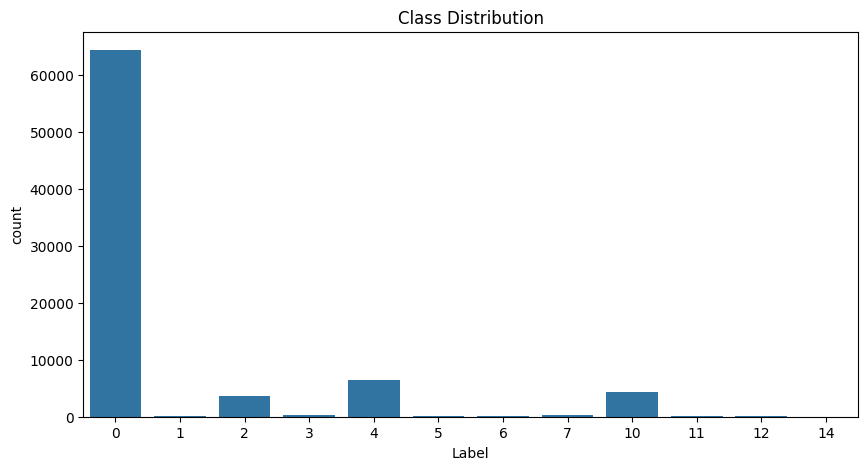

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Label'])
plt.title("Class Distribution")
plt.show()

In [19]:

corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Dropping:", len(to_drop))

df = df.drop(columns=to_drop)

X = df.drop('Label', axis=1)
y = df['Label']

Dropping: 33


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Ensure same columns
X_test = X_test[X_train.columns]

print(X_train.shape, X_test.shape)

(63997, 45) (16000, 45)


In [21]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=15,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ),

    "Linear SVM": LinearSVC(
        class_weight='balanced'
    )
}

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

print("\nAll models trained successfully.")


Training Random Forest...

Training Logistic Regression...

Training Linear SVM...

All models trained successfully.



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12866
           1       0.30      0.30      0.30        10
           2       1.00      1.00      1.00       726
           3       1.00      0.95      0.97        61
           4       0.98      1.00      0.99      1299
           5       1.00      1.00      1.00        32
           6       1.00      0.94      0.97        31
           7       1.00      0.98      0.99        49
          10       1.00      1.00      1.00       882
          11       1.00      1.00      1.00        31
          12       0.75      0.67      0.71         9
          14       0.00      0.00      0.00         4

    accuracy                           1.00     16000
   macro avg       0.84      0.82      0.83     16000
weighted avg       1.00      1.00      1.00     16000



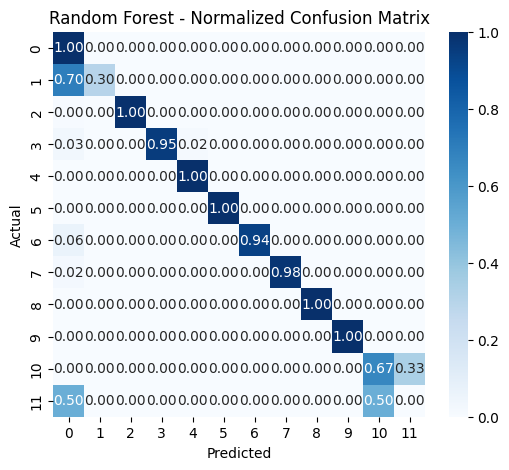


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     12866
           1       0.01      1.00      0.02        10
           2       0.71      1.00      0.83       726
           3       0.48      0.95      0.64        61
           4       0.85      0.99      0.91      1299
           5       0.43      1.00      0.60        32
           6       0.43      0.90      0.58        31
           7       0.25      0.98      0.39        49
          10       0.83      0.99      0.90       882
          11       0.09      1.00      0.17        31
          12       0.00      0.00      0.00         9
          14       0.02      1.00      0.04         4

    accuracy                           0.83     16000
   macro avg       0.42      0.88      0.50     16000
weighted avg       0.96      0.83      0.88     16000



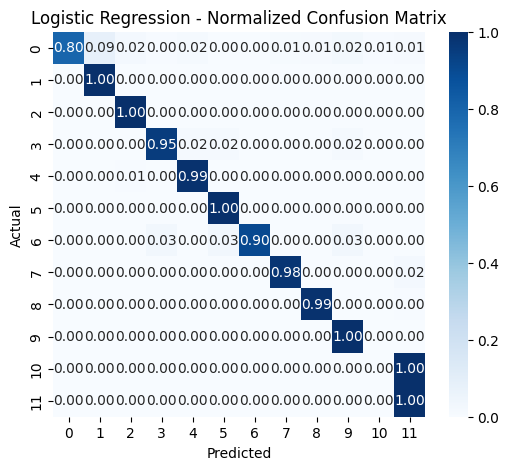


Linear SVM
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     12866
           1       0.02      0.30      0.04        10
           2       0.76      1.00      0.86       726
           3       0.48      0.93      0.64        61
           4       0.89      0.97      0.93      1299
           5       0.75      0.94      0.83        32
           6       0.67      0.65      0.66        31
           7       0.55      0.98      0.70        49
          10       0.84      0.99      0.91       882
          11       0.20      1.00      0.34        31
          12       0.00      0.00      0.00         9
          14       0.03      1.00      0.07         4

    accuracy                           0.93     16000
   macro avg       0.51      0.81      0.58     16000
weighted avg       0.96      0.93      0.94     16000



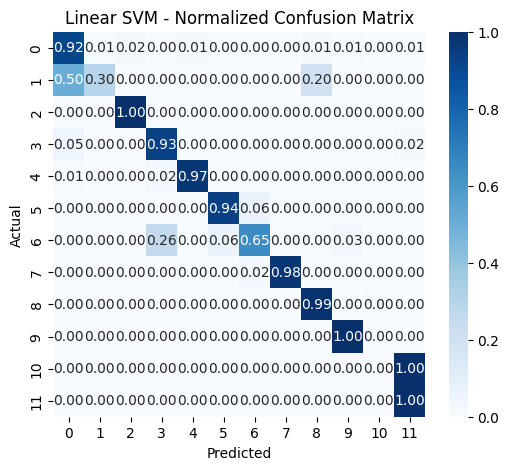

In [23]:
for name, model in trained_models.items():
    print(f"\n{name}")

    y_pred = model.predict(X_test_scaled)

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues")
    plt.title(f"{name} - Normalized Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

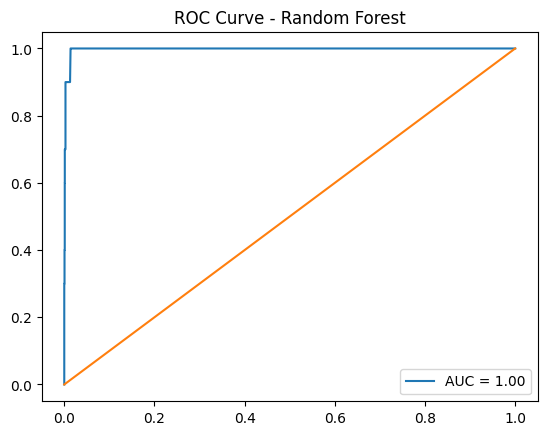

In [24]:
rf = trained_models["Random Forest"]

y_prob = rf.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1])
plt.legend()
plt.title("ROC Curve - Random Forest")
plt.show()

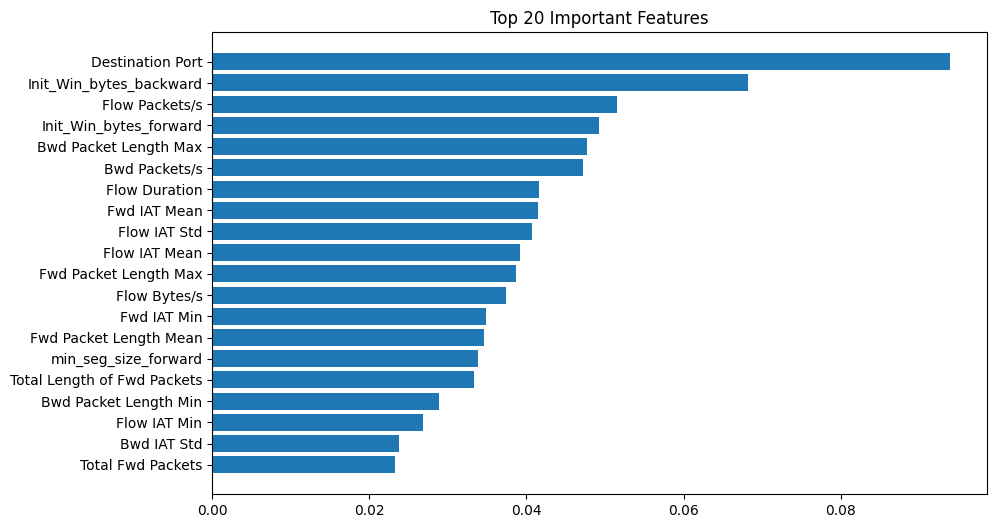

In [25]:
rf = trained_models["Random Forest"]

importances = rf.feature_importances_
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 20 Important Features")
plt.show()

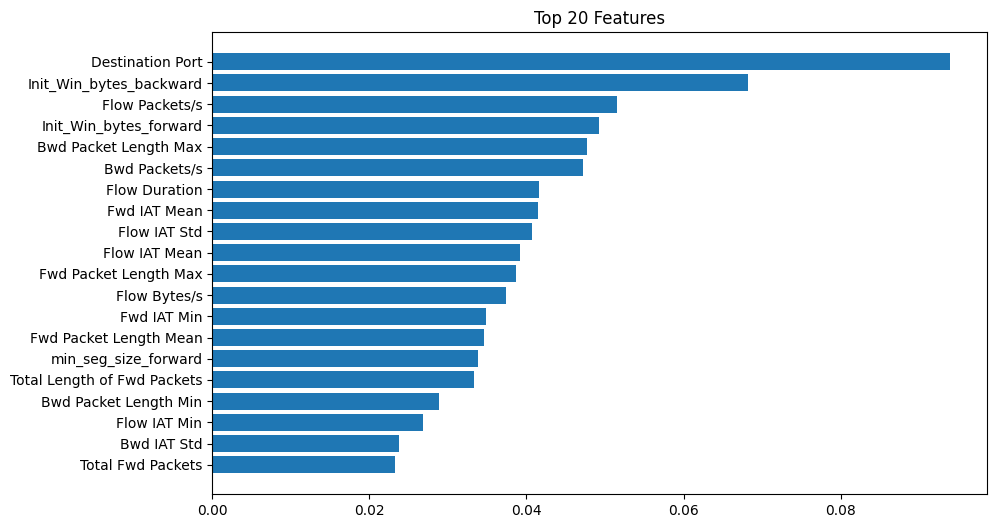

In [26]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 20 Features")
plt.show()

In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, n_jobs=-1)

grid.fit(X_train_res, y_train_res)

print("Best Params:", grid.best_params_)

NameError: name 'RandomForestClassifier' is not defined

In [ ]:

joblib.dump(rf, "ids_model.pkl")

print("Model saved successfully.")